# Introduction to Data Science 2026

# Week 6: Recap

## Exercise 1 | Linear regression with feature selection

Download the [TED Talks](https://www.kaggle.com/rounakbanik/ted-talks) dataset from Kaggle. Your task is to predict both the ratings and the number of views of a given TED talk. You should focus only on the <span style="font-weight: bold">ted_main</span> table.

1. Download the data, extract the following ratings from column <span style="font-weight: bold">ratings</span>: <span style="font-weight: bold">Funny</span>, <span style="font-weight: bold">Confusing</span>, <span style="font-weight: bold">Inspiring</span>. Store these values into respective columns so that they are easier to access. Next, extract the tags from column <span style="font-weight: bold">tags</span>. Count the number of occurrences of each tag and select the top-100 most common tags. Create a binary variable for each of these and include them in your data table, so that you can directly see whether a given tag (among the top-100 tags) is used in a given TED talk or not. The dataset you compose should have dimension (2550, 104), and comprise of the 'views' column, the three columns with counts of "Funny", "Confusing and "Inspiring" ratings, and 100 columns which one-hot encode the top-100 most common tag columns.


In [1]:
import ast
from collections import Counter
import numpy as np
import pandas as pd

df = pd.read_csv("ted_main.csv")

# ratings and tags are stored as strings that look like Python lists
ratings = df["ratings"].apply(ast.literal_eval)
tags = df["tags"].apply(ast.literal_eval)

# one column per rating we care about
for name in ["Funny", "Confusing", "Inspiring"]:
    df[name] = ratings.apply(lambda r: [x["count"] for x in r if x["name"] == name][0])

# top-100 most common tags, one binary column each
tag_counts = Counter(t for ts in tags for t in ts)
top_tags = [t for t, _ in tag_counts.most_common(100)]
tag_df = pd.DataFrame({"tag_" + t: tags.apply(lambda ts: int(t in ts)) for t in top_tags})
df = pd.concat([df, tag_df], axis=1)

tag_cols = list(tag_df.columns)
data = df[["views", "Funny", "Confusing", "Inspiring"] + tag_cols]
print(data.shape)
data.head()

(2550, 104)


,views,Funny,Confusing,Inspiring,tag_technology,tag_science,tag_global issues,tag_culture,tag_TEDx,tag_design,...,tag_food,tag_religion,tag_peace,tag_ecology,tag_family,tag_demo,tag_poetry,tag_illness,tag_universe,tag_energy
0,47227110,19645,242,24924,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,3200520,544,62,413,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1636292,964,27,230,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1697550,59,32,1070,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,12005869,1390,72,2893,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0


2. Construct a linear regression model to predict the number of views based on the data in the <span style="font-weight: bold">ted_main</span> table, including the binary variables for the top-100 tags that you just created.

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# other numeric columns of ted_main plus the tag columns
num_cols = ["comments", "duration", "languages", "num_speaker", "film_date", "published_date"]
X = pd.concat([df[num_cols], df[tag_cols]], axis=1)

def fit_linear(target):
    X_train, X_test, y_train, y_test = train_test_split(X, df[target], test_size=0.2, random_state=0)
    model = LinearRegression().fit(X_train, y_train)
    print(f"{target}: train R2 = {model.score(X_train, y_train):.3f}, test R2 = {r2_score(y_test, model.predict(X_test)):.3f}")
    return model

views_model = fit_linear("views")

views: train R2 = 0.308, test R2 = 0.168


3. Do the same for the <span style="font-weight: bold">Funny</span>, <span style="font-weight: bold">Confusing</span>, and <span style="font-weight: bold">Inspiring</span> ratings.

In [3]:
# same model for the three ratings
rating_models = {r: fit_linear(r) for r in ["Funny", "Confusing", "Inspiring"]}

Funny: train R2 = 0.147, test R2 = 0.060
Confusing: train R2 = 0.186, test R2 = 0.157
Inspiring: train R2 = 0.330, test R2 = 0.189


4. You will probably notice that most of the tags are not useful in predicting the views and the ratings. You should use some kind of variable selection to prune the set of tags that are included in the model. You can use for example classical p-values or more modern [LASSO](https://en.wikipedia.org/wiki/Lasso_(statistics)) techniques. Which tags are the best predictors of each of the response variables?

In [4]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

# standardise X and y so the Lasso penalty treats all variables equally
X_scaled = StandardScaler().fit_transform(X)

selected = {}
for target in ["views", "Funny", "Confusing", "Inspiring"]:
    y = (df[target] - df[target].mean()) / df[target].std()
    lasso = LassoCV(cv=5, random_state=0).fit(X_scaled, y)
    coefs = pd.Series(lasso.coef_, index=X.columns)
    coefs = coefs[coefs != 0]
    selected[target] = coefs.sort_values(key=abs, ascending=False)
    print(f"{target}: {len(coefs)} variables kept")
    print(selected[target].head(10).round(3).to_string())
    print()

views: 49 variables kept
comments             0.464
languages            0.245
published_date       0.104
tag_psychology       0.090
tag_religion        -0.079
duration             0.078
tag_global issues   -0.071
tag_humor            0.054
tag_work             0.051
tag_motivation       0.046

Funny: 26 variables kept
comments             0.332
tag_humor            0.270
languages            0.083
tag_entertainment    0.069
tag_global issues   -0.048
tag_work             0.047
tag_creativity       0.044
tag_mind             0.037
tag_religion        -0.034
tag_children         0.032

Confusing: 47 variables kept
comments             0.298
published_date      -0.163
tag_brain            0.062
tag_physics          0.062
tag_evolution        0.058
tag_philosophy       0.057
tag_humor            0.042
tag_psychology       0.040
tag_global issues   -0.038
tag_math             0.031

Inspiring: 47 variables kept
comments             0.527
languages            0.106
tag_religion        -0.08

5. Produce summaries of your results. Could you recommend good tags – or tags to avoid! – for speakers targeting plenty of views and/or certain ratings?

In [5]:
# best and worst tags for each response, based on the Lasso coefficients
for target, coefs in selected.items():
    tag_coefs = coefs[coefs.index.str.startswith("tag_")]
    tag_coefs.index = tag_coefs.index.str.replace("tag_", "", regex=False)
    print(f"--- {target} ---")
    print("Good tags:", list(tag_coefs[tag_coefs > 0].sort_values(ascending=False).index[:5]))
    print("Tags to avoid:", list(tag_coefs[tag_coefs < 0].sort_values().index[:5]))
    print()

--- views ---
Good tags: ['psychology', 'humor', 'work', 'motivation', 'performance']
Tags to avoid: ['religion', 'global issues', 'philosophy', 'neuroscience', 'politics']

--- Funny ---
Good tags: ['humor', 'entertainment', 'work', 'creativity', 'mind']
Tags to avoid: ['global issues', 'religion', 'neuroscience', 'philosophy', 'design']

--- Confusing ---
Good tags: ['brain', 'physics', 'evolution', 'philosophy', 'humor']
Tags to avoid: ['global issues', 'animals', 'Africa', 'health care', 'music']

--- Inspiring ---
Good tags: ['mental health', 'work', 'psychology', 'happiness', 'life']
Tags to avoid: ['religion', 'neuroscience', 'economics', 'science', 'philosophy']



**Answer (Exercise 1, question 5)**

The linear models explain only a small part of the variation on unseen data. Test R² is 0.17 for views, 0.06 for Funny, 0.16 for Confusing and 0.19 for Inspiring, and train R² is clearly higher than test R², so the models also overfit a little. Tags (together with a few other numeric columns) are therefore weak predictors, and the recommendations below are tendencies, not guarantees. Lasso kept 49 variables for views, 26 for Funny, 47 for Confusing and 47 for Inspiring.

The strongest predictor in every model is the number of comments, and for views also the number of languages. A speaker cannot choose these, and they mostly follow from a talk already being popular, so they partly reflect the response instead of causing it. The rating counts also grow with the number of views, so tags that help views tend to help the rating counts too.

Among the tags:
- **Views:** psychology, humor, work, motivation and performance go with more views. Religion, global issues, philosophy, neuroscience and politics go with fewer views.
- **Funny:** humor is by far the strongest tag in any model, followed by entertainment, work, creativity and mind. Global issues, religion, neuroscience and philosophy go with fewer Funny votes.
- **Confusing:** brain, physics, evolution and philosophy go with more Confusing votes, which fits the fact that abstract science topics are harder to follow. Global issues, animals, Africa, health care and music go with fewer.
- **Inspiring:** mental health, work, psychology, happiness and life go with more Inspiring votes. Religion, neuroscience, economics and science go with fewer.

**Recommendation:** a speaker who wants many views should consider tags like psychology, humor, work and motivation, and should be careful with religion, global issues and philosophy. For a funny talk, use humor and entertainment. For an inspiring talk, use mental health, happiness and life. These are associations in past data, not causal effects, since the tags describe the talk and are not what makes it popular.

**Remember to submit your code on the MOOC platform. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**

## Exercise 2 | Symbol classification (part 2)

Note that it is strongly recommended to use Python in this exercise. However, if you can find a suitable AutoML implementation for your favorite language (e.g [here](http://h2o-release.s3.amazonaws.com/h2o/master/3888/docs-website/h2o-docs/automl.html) seems to be one for R) then you are free to use that language as well.

Use the preprocessed data from week 3 (you can also produce them using the example solutions of week 3).

1. This time train a *random forest classifier* on the data. A random forest is a collection of *decision trees*, which makes it an *ensemble* of classifiers. Each tree uses a random subset of the features to make its prediction. Without tuning any parameters, how is the accuracy?

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Preprocessed data from week 3: HASYv2 symbols with symbol_id 70 to 79
labels = pd.read_csv("hasy-data-labels.csv")
subset = labels[(labels["symbol_id"] >= 70) & (labels["symbol_id"] <= 79)].reset_index(drop=True)

X_sym = np.zeros((len(subset), 32 * 32), dtype=np.uint8)
y_sym = subset["symbol_id"].to_numpy()
for i, path in enumerate(subset["path"]):
    X_sym[i, :] = np.asarray(Image.open(path).convert("L")).flatten()
print(X_sym.shape, y_sym.shape)

# same shuffle and 80/20 split as in week 3
rng = np.random.default_rng(42)
idx = rng.permutation(len(X_sym))
X_shuffled, y_shuffled = X_sym[idx], y_sym[idx]
split_point = int(0.8 * len(X_sym))
X_train, X_test = X_shuffled[:split_point], X_shuffled[split_point:]
y_train, y_test = y_shuffled[:split_point], y_shuffled[split_point:]

rf = RandomForestClassifier(random_state=0)
rf.fit(X_train, y_train)
print("Test accuracy:", rf.score(X_test, y_test))

(1020, 1024) (1020,)
Test accuracy: 0.8578431372549019


2. The amount of trees to use as a part of the random forest is an example of a hyperparameter, because it is a parameter that is set prior to the learning process. In contrast, a parameter is a value in the model that is learned from the data. Train 20 classifiers, with varying amounts of decision trees starting from 10 up until 200, and plot the test accuracy as a function of the amount of classifiers. Does the accuracy keep increasing? Is more better?

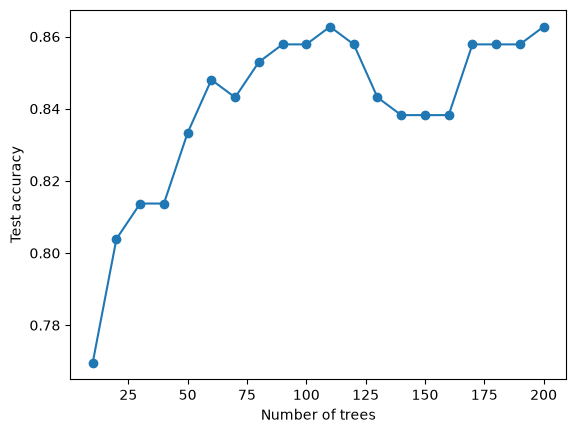

In [7]:
n_trees = list(range(10, 201, 10))  # 20 values
accs = []
for n in n_trees:
    clf = RandomForestClassifier(n_estimators=n, random_state=0).fit(X_train, y_train)
    accs.append(clf.score(X_test, y_test))

plt.plot(n_trees, accs, marker="o")
plt.xlabel("Number of trees")
plt.ylabel("Test accuracy")
plt.show()

**Answer (Exercise 2, question 2)**

The accuracy rises quickly at first, from about 0.77 with 10 trees to about 0.85 with 60 to 90 trees, and after that it stops increasing in a clear way. It reaches 0.863 at 110 trees, drops to about 0.84 for 140 to 160 trees and is back at 0.863 at 200 trees. The test set has 204 images, so one image is about 0.5 percentage points, and the ups and downs after 90 trees are only a few images. More trees is therefore better at the start, but beyond roughly 100 trees there is no real gain, only noise (and a longer training time).

3. If we had picked the amount of decision trees by taking the value with the best test accuracy from the last plot, we would have *overfit* our hyperparameters to the test data. Can you see why it is a mistake to tune hyperparameters of your model by using the test data?

If we choose the number of trees (or any other hyperparameter) by looking at the test accuracy, the test set is no longer independent of the model, because we used it to make a modelling decision. The best test accuracy is then optimistically biased, since it partly reflects luck on that particular test set, and it no longer tells us how the model performs on new data. The test set should be used only once, at the very end. Hyperparameters should be tuned on a separate validation set (or with cross-validation).

4. Reshuffle and resplit the data so that it is divided in 3 parts: training (80%), validation (10%) and test (10%). Repeatedly train a model of your choosing (e.g random forest) on the training data, and evaluate it’s performance on the validation set, while tuning the hyperparameters so that the accuracy on the validation set increases. Then, finally evaluate the performance of your model on the test data. What can you say in terms of the generalization of your model?

In [8]:
# 80% train, 10% validation, 10% test
X_tr, X_rest, y_tr, y_rest = train_test_split(X_sym, y_sym, test_size=0.2, random_state=1)
X_val, X_te, y_val, y_te = train_test_split(X_rest, y_rest, test_size=0.5, random_state=1)

best_acc, best_params = 0, None
for n in [10, 50, 100, 200]:
    for depth in [None, 10, 20]:
        clf = RandomForestClassifier(n_estimators=n, max_depth=depth, random_state=0).fit(X_tr, y_tr)
        val_acc = clf.score(X_val, y_val)
        if val_acc > best_acc:
            best_acc, best_params = val_acc, (n, depth)

print("Best params (n_estimators, max_depth):", best_params)
print("Validation accuracy:", best_acc)

final = RandomForestClassifier(n_estimators=best_params[0], max_depth=best_params[1], random_state=0).fit(X_tr, y_tr)
print("Test accuracy:", final.score(X_te, y_te))
# If the test accuracy is close to the validation accuracy, the model generalises well.

Best params (n_estimators, max_depth): (200, 20)
Validation accuracy: 0.8627450980392157
Test accuracy: 0.8627450980392157


**Answer (Exercise 2, question 4)**

The best setting on the validation set was 200 trees with a maximum depth of 20, which gave a validation accuracy of 0.863. The final test accuracy was also 0.863. The two values are the same, so the model does not seem to be overfitted to the validation set, and we can expect roughly 86% accuracy on new symbols from the same data. This is only a rough estimate, because the validation and test sets have just 102 images each (one image is about 1 percentage point), so the real accuracy could be a few points higher or lower. The tuning also gained little compared to the default forest (0.858 in question 1), so the model generalises about as well as it did without tuning.

**Remember to submit your code on the MOOC platform. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**

## Exercise 3 | TPOT

The process of picking a suitable model, evaluating its performance and tuning the hyperparameters is very time consuming. A new idea in machine learning is the concept of automating this by using an optimization algorithm to find the best model in the space of models and their hyperparameters. Have a look at [TPOT](https://github.com/EpistasisLab/tpot), an automated ML solution that finds a good model and a good set of hyperparameters automatically. Try it on this data, it should outperform simple models like the ones we tried easily. Note that running the algorithm might take a while, depending on the strength of your computer. 

*Note*: In case it is running for too long, try checking if the parameters you are using when calling TPOT are reasonable, i.e. try reducing number of ‘generations’ or ‘population_size’. TPOT uses cross-validation internally, so we don’t need our own validation set.

In [9]:
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from tpot import TPOTClassifier

# TPOT works with classes 0..n-1, so encode the symbol ids (70 to 79) first
le = LabelEncoder().fit(y_train)

# small settings so it finishes in a few minutes; TPOT does its own cross-validation
tpot = TPOTClassifier(generations=3, population_size=10, cv=5, max_time_mins=5,
                      n_jobs=4, random_state=0, verbose=1)
tpot.fit(X_train, le.transform(y_train))

y_pred = le.inverse_transform(tpot.predict(X_test))
print("TPOT test accuracy:", accuracy_score(y_test, y_pred))

c:\Users\Abtaal\University of Helsinki\Semester 1\Period 1\Data Science (DATA11001)\Assignments\Week 6\.venv\Lib\site-packages\stopit\__init__.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
c:\Users\Abtaal\University of Helsinki\Semester 1\Period 1\Data Science (DATA11001)\Assignments\Week 6\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Abtaal\University of Helsinki\Semester 1\Period 1\Data Science (DATA11001)\Assignments\Week 6\.venv\Lib\site-packages\tpot\tpot_estimator\estimator.py:458: UserWarning: Both generations and max_time_mins are set. TPOT will terminate when the fi

TPOT test accuracy: 0.8872549019607843


**Answer (Exercise 3)**

TPOT reached a test accuracy of 0.887, which is higher than the default random forest (0.858) on the same test set. The gain is about 3 percentage points, which is around 6 of the 204 test images, so it is a modest improvement and could partly be noise. TPOT also finished with small settings (3 generations and a population of 10), so a longer search might find a better pipeline. The main benefit is that it found a good model without us tuning anything by hand.

**Remember to submit your code on the MOOC platform. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**